# MNIST Neural Network with Dropout and Hyperparameter Tuning

Epoch 1/5
1500/1500 [==============================] - 8s 5ms/step - loss: 0.2867 - accuracy: 0.9180 - val_loss: 0.1536 - val_accuracy: 0.9571
Epoch 2/5
1500/1500 [==============================] - 11s 7ms/step - loss: 0.1315 - accuracy: 0.9617 - val_loss: 0.1247 - val_accuracy: 0.9627
Epoch 3/5
1500/1500 [==============================] - 16s 11ms/step - loss: 0.0899 - accuracy: 0.9733 - val_loss: 0.1057 - val_accuracy: 0.9676
Epoch 4/5
1500/1500 [==============================] - 14s 9ms/step - loss: 0.0668 - accuracy: 0.9801 - val_loss: 0.0888 - val_accuracy: 0.9737
Epoch 5/5
313/313 [==============================] - 5s 10ms/step - loss: 0.0858 - accuracy: 0.9746
Test Accuracy: 0.9746000170707703


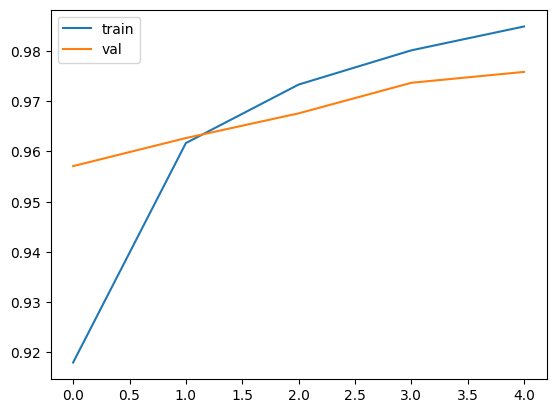

Epoch 1/5
1500/1500 [==============================] - 14s 7ms/step - loss: 0.3521 - accuracy: 0.8969 - val_loss: 0.1612 - val_accuracy: 0.9548
Epoch 2/5
1500/1500 [==============================] - 9s 6ms/step - loss: 0.1784 - accuracy: 0.9475 - val_loss: 0.1255 - val_accuracy: 0.9630
Epoch 3/5
1500/1500 [==============================] - 10s 6ms/step - loss: 0.1365 - accuracy: 0.9589 - val_loss: 0.0988 - val_accuracy: 0.9714
Epoch 4/5
1500/1500 [==============================] - 13s 9ms/step - loss: 0.1133 - accuracy: 0.9656 - val_loss: 0.0916 - val_accuracy: 0.9736
Epoch 5/5
313/313 [==============================] - 1s 3ms/step - loss: 0.0801 - accuracy: 0.9764
   Learning Rate  Batch Size  Accuracy
0          0.010          32    0.9582
1          0.010          64    0.9611
2          0.001          32    0.9732
3          0.001          64    0.9703
         Model  Accuracy
0          ANN    0.9746
1  Dropout ANN    0.9764


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd

(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()
X_train=X_train/255.0
X_test=X_test/255.0

model=keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128,activation="relu"),
    layers.Dense(10,activation="softmax")
])
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
h=model.fit(X_train,y_train,epochs=5,validation_split=0.2)
loss,acc=model.evaluate(X_test,y_test)
print("Test Accuracy:",acc)

plt.plot(h.history["accuracy"],label="train")
plt.plot(h.history["val_accuracy"],label="val")
plt.legend();plt.show()

drop=keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10,activation="softmax")
])
drop.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
drop.fit(X_train,y_train,epochs=5,validation_split=0.2)
_,drop_acc=drop.evaluate(X_test,y_test)

results=[]
for lr in [0.01,0.001]:
    for bs in [32,64]:
        m=keras.Sequential([
            layers.Flatten(input_shape=(28,28)),
            layers.Dense(128,activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(10,activation="softmax")
        ])
        m.compile(optimizer=keras.optimizers.Adam(lr),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
        m.fit(X_train,y_train,epochs=3,batch_size=bs,verbose=0)
        _,a=m.evaluate(X_test,y_test,verbose=0)
        results.append([lr,bs,a])
print(pd.DataFrame(results,columns=["Learning Rate","Batch Size","Accuracy"]))
print(pd.DataFrame({"Model":["ANN","Dropout ANN"],"Accuracy":[acc,drop_acc]}))
